### 포켓몬스터 공식 사이트에서 이미지 데이터를 수집하자
- 바탕화면에 "포켓몬도감"이라는 폴더 생성
- 이미지 데이터를 폴더 안에 담아보자

In [1]:
from selenium import webdriver as wb
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import time
import os
from urllib.request import urlretrieve

In [3]:
# 바탕화면에 "포켓몬도감"폴더 생성 -> os라이브러리 사용
#if os.path.isdir("C:/Users/smhrd/Desktop/포켓몬도감"): #역슬래시는 이스케이프 코드. 탈출하는 기능이 있기 때문에 그냥 슬래시로 바꿔줘야 한다.
# 해석 : 운영체제야, 다음과 같은 경로에 다음과 같은 폴더가 있어?
    #print("해당 폴더가 이미 존재합니다.")    
#else:
    # 질문 값이 폴스니까 엘스에 폴더 생성해주는 코드
    #print("폴더가 생성되었습니다.")

In [4]:
if not os.path.isdir("C:/Users/smhrd/Desktop/포켓몬도감"):
    os.mkdir("C:/Users/smhrd/Desktop/포켓몬도감")
    print("폴더가 생성되었습니다.")
else:
    print("해당 폴더가 이미 존재합니다.")     #위랑 똑같지만 폴더 만드는 코드를 이프문 안에 넣어서 가독성 좋게 만듬

해당 폴더가 이미 존재합니다.


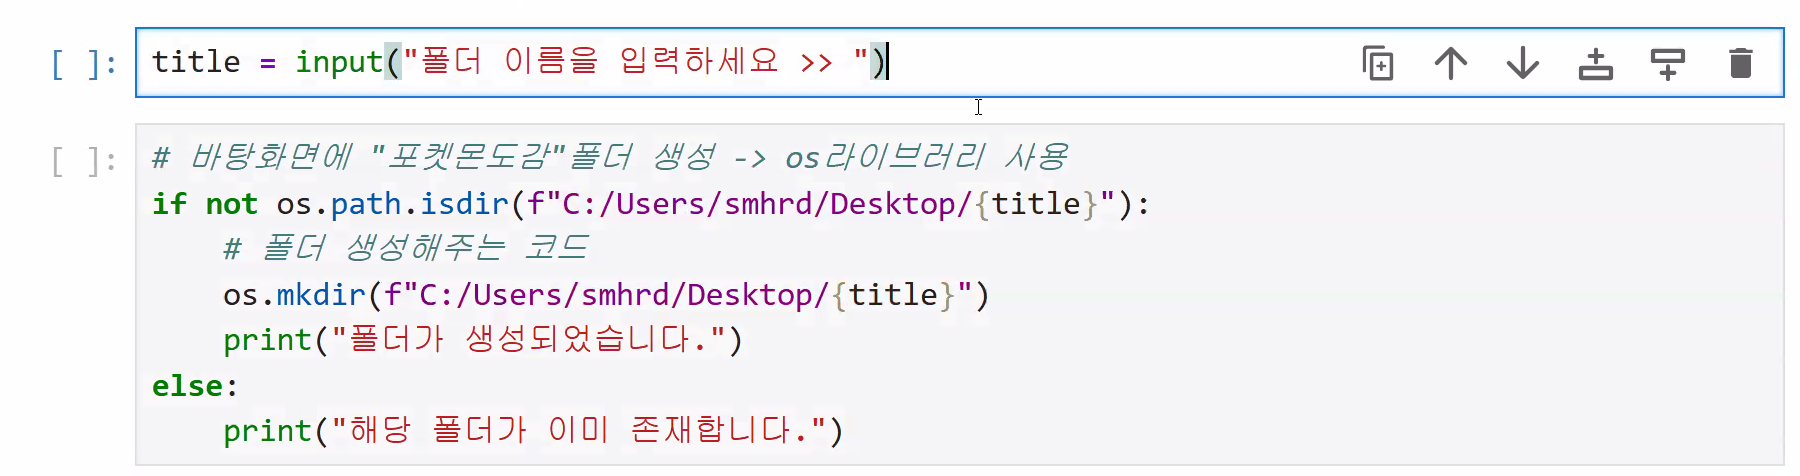

#### ->나중에 크롤링 코드 저장하고 싶거나 할때 위 사진처럼 만들어두면 편함

In [9]:
# 포켓몬스터 공식 페이지 url 가져오기
from selenium.webdriver.chrome.service import Service
# 사용자가 사용하는 최신버전의 크롬 드라이버와 일치하는 드라이버를 찾아주는 라이브러리
from webdriver_manager.chrome import ChromeDriverManager
# 최신버전의 크롬 드라이버를 찾고 다운로드 해주는 라이브러리
# ChromeDriverManager().install()  : 크롬드라이버 업데이트 및 설치
s = Service(ChromeDriverManager().install())
driver = wb.Chrome(service = s)
driver.get("https://pokemonkorea.co.kr/pokedex")

In [8]:
# 객체화
from bs4 import BeautifulSoup as bs
soup = bs(driver.page_source, 'lxml')

In [12]:
# 정적 크롤링에서 사진 수집
img = soup.select('img.img-fluid')
img[0]['src']

'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000101.png'

In [13]:
# 동적 크롤링에서 사진 수집
img2 = driver.find_elements(By.CSS_SELECTOR, 'img.img-fluid' )
img2[0].get_attribute('src')  #attribute: 속성. src 속성값으로 사진을 가져오겠다.

'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000101.png'

In [15]:
# 빈 리스트에 img태그가 가진 src값만 모아보자
img_lst = []
for i in range(len(img)):
    img_lst.append(img[i]['src'])
img_lst

['https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000101.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000201.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000301.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000302.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000303.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000401.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000501.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000601.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000602.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000603.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000604.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000701.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000801.png',
 'https://data1.pokemonkorea.co.kr/newdata/pokedex/mid/000901.png',
 'https://data1.pokemonkorea.co.kr/newdata/poked

-  이미지 경로(src) 값을 활용해서 이미지 파일로 변환해주는 라이브러리 사용!

In [16]:
# 이미지 파일로 저장
urlretrieve(img_lst[0], "C:/Users/smhrd/Desktop/포켓몬도감/1번포켓몬.jpg")

('C:/Users/smhrd/Desktop/포켓몬도감/1번포켓몬.jpg',
 <http.client.HTTPMessage at 0x189b1bfe2b0>)

In [17]:
# 반복문 써서 포켓몬 이미지 데이터 수집
for i in range(len(img_lst)):
    urlretrieve(img_lst[i], f"C:/Users/smhrd/Desktop/포켓몬도감/{i+1}번포켓몬.jpg") #한번에 몇천개의 포켓몬 데이터를 화면에 표시하면 서버 부하가 걸리니까
                                                                                  # 스크롤내리면 포켓몬이 계속 나오도록 되어있음. 대부분 사이트가 그럼

#### 화면에서 스크롤 내리는 방법
- 수집된 포켓몬의 갯수가 너무 적다.
- 키보드로 스크롤 내리는 4가지 방법
- space bar
- ↓
- end
- page down

In [20]:
# 키보드에 있는end키를 사용해서 스크롤을 내려보자 -> 자동스크롤 (4개 방법중 end가 제일 많이 내려가서 사용)
# 화면 전체를 담당하고 있는 body태그에게 부탁 -> 우리 보통 스크롤할때 빈곳 클릭하고 하니까. 빈곳이 바디 태그이다
body = driver.find_element(By.CSS_SELECTOR, "body")
for i in range(20):
    body.send_keys(Keys.END)
    time.sleep(2)

# 스크롤 끝까지 내리는 코드

# 스크롤 현재(가장 최근) 높이 저장
last_height = driver.execute_script("return document.body.scrollHeight")

while True:
    # 맨 밑까지 스크롤 내리기
    body.send_keys(Keys.END)

    # 페이지 로드 되는 것 기다리기
    time.sleep(1)

    # 스크롤 전체 높이와 지금까지 내린 스크롤 높이를 비교하는 코드
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == last_height:  # 만약 현재 높이와 스크롤 전체 높이가 같아지면
        break    # 반복문을 빠져나가주세요
    last_height = new_height

In [ ]:
- 실습 : 이미지 데이터 크롤링

In [35]:
# 한 셀만 실행해도 내가 원하는 포켓몬이 전부 잡힐 수 있도록 로직 구현 
# --> ⭐순서가 중요⭐
#from selenium import webdriver as wb
#from selenium.webdriver.common.keys import Keys
#from selenium.webdriver.common.by import By
#import time
#import os
#from urllib.request import urlretrieve

# 바탕화면에 "포켓몬도감"폴더 생성 -> os라이브러리 사용
if not os.path.isdir("C:/Users/smhrd/Desktop/포켓몬도감"):
    # 폴더 생성해주는 코드
    os.mkdir("C:/Users/smhrd/Desktop/포켓몬도감")
    print("폴더가 생성되었습니다.")
else:
    print("해당 폴더가 이미 존재합니다.")

# 포켓몬스터 공식 페이지 url 가져오기
driver = wb.Chrome()
driver.get("https://pokemonkorea.co.kr/pokedex")
time.sleep(2)

# 스크롤 20번 내리기
body = driver.find_element(By.CSS_SELECTOR, "body")
for i in range(20):
    body.send_keys(Keys.END)
    time.sleep(2)

# 캡처하는건 내가 스크롤을 다 내린 후에
from bs4 import BeautifulSoup as bs
soup = bs(driver.page_source, 'lxml')
img = soup.select('img.img-fluid')
poke_name = driver.find_elements(By.CSS_SELECTOR, "div.bx-txt > h3")

# 이미지 src값만 수집
img_lst = []
for i in range(len(img)):
    img_lst.append(img[i]['src'])

name_lst = []
for poke in poke_name:
    name_lst.append(poke.text[8:])

# 수집된 src값을 모두 이미지 파일로 변환
for i in range(len(img_lst)):
    urlretrieve(img_lst[i], f"C:/Users/smhrd/Desktop/포켓몬도감/{name_lst[i]}.jpg")

해당 폴더가 이미 존재합니다.


#### 번외 : 포켓몬 이름 지정하자


In [36]:
poke_name = driver.find_elements(By.CSS_SELECTOR, "div.bx-txt > h3")
poke_name[0].text

'No.0001\n이상해씨'

In [37]:
poke_name[0].text[8:]

'이상해씨'

In [38]:
name_lst = []
for poke in poke_name:
    name_lst.append(poke.text[8:])
    name_lst

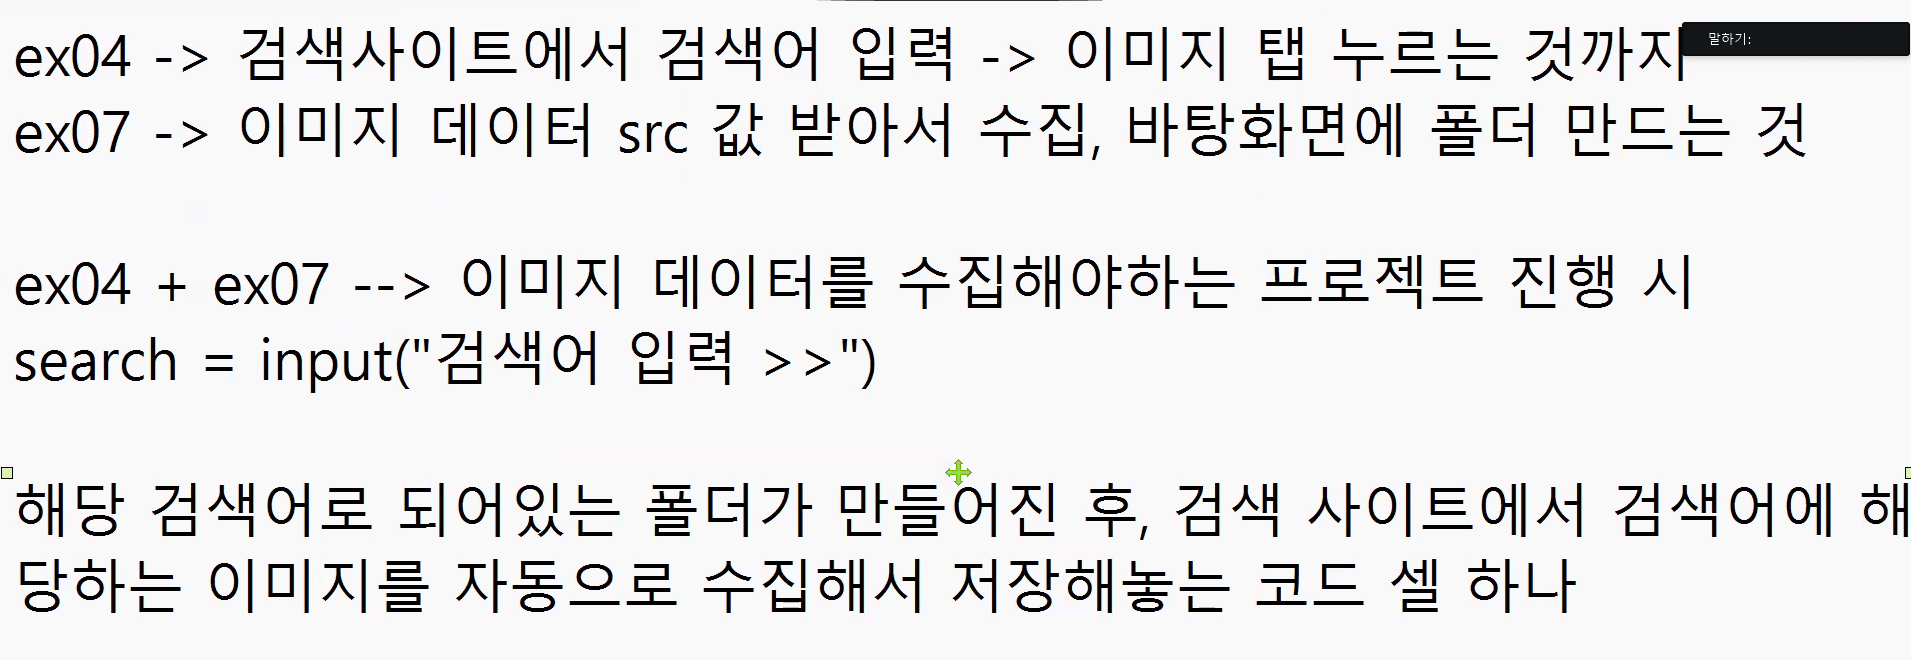